# Analyse des Betriebsverhaltens einer Turbomaschine

In [22]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### 1. Messdaten laden und anzeigen

Dieser Abschnitt lädt die Messdaten aus einer CSV-Datei und zeigt die ersten Zeilen zur Überprüfung an.

In [23]:
# Dateipfad der Messdaten
filename = '/content/volume_flow_data.csv'

# Messdaten in DataFrame laden
df = pd.read_csv(filename)

# Erste Zeilen anzeigen
display(df.head())

,Timestamp,Volume Flow (m^3/h)
0,2024-04-01 00:00:00,312.54
1,2024-04-01 00:01:00,193.78
2,2024-04-01 00:02:00,393.96
3,2024-04-01 00:03:00,364.70
4,2024-04-01 00:04:00,100.33


### 2. Pumpenkennfelder definieren

Hier werden die Leistungsdaten der Pumpe (Volumenstrom, Förderhöhe, Wirkungsgrad) definiert und Interpolationsfunktionen erstellt.

In [24]:
# Stützpunkte des Pumpenkennfelds (Herstellerdaten)
Q_points = np.array([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 560]) # Volumenstrom (m³/h)
H_points = np.array([23.4, 23.0, 22.5, 22.0, 21.2, 20.0, 18.5, 17.0, 15.2, 13.2, 11.2, 8.8]) # Förderhöhe (m)
eta_points = np.array([0.01, 25.0, 45.0, 55.0, 64.0, 71.3, 73.5, 74.5, 75.0, 74.0, 72.0, 68.0]) / 100.0 # Wirkungsgrad

# Kubische Interpolationsfunktionen erstellen
f_H = interp1d(Q_points, H_points, kind='cubic', fill_value='extrapolate')
f_eta = interp1d(Q_points, eta_points, kind='cubic', fill_value='extrapolate')

### 3. Datenvorbereitung und Glättung

Dieser Abschnitt bereitet die Messdaten auf, indem Zeitstempel formatiert, die Förderhöhe und der Wirkungsgrad berechnet und der Volumenstrom geglättet werden.

In [30]:
# Spaltenname für Volumenstrom
col_flow = 'Volume Flow (m^3/h)'

# Zeitstempel formatieren
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Förderhöhe (H_m) und Pumpenwirkungsgrad (eta_pump) berechnen
df['H_m'] = f_H(df[col_flow])
df['eta_pump'] = np.clip(f_eta_pump(df[col_flow]), 0.01, 1.0) # Wirkungsgrad begrenzen (min. 1%)

# Volumenstrom glätten (gleitender Mittelwert über 15 Minuten)
df['Q_smoothed'] = df[col_flow].rolling(window=15, min_periods=1).mean()

### 4. Physikalische und Wirtschaftliche Berechnungen

Hier werden hydraulische und elektrische Leistungen, Energieverbräuche sowie die entsprechenden Kosten berechnet.

In [26]:
# Konstanten
rho = 1000 # Dichte Wasser (kg/m³)
g = 9.81   # Erdbeschleunigung (m/s²)
strompreis = 0.18 # Strompreis (€ / kWh)
delta_t_h = 1 / 60 # Messintervall in Stunden (1 Minute)

# Hydraulische Leistung (Watt)
df['P_hyd_W'] = rho * g * (df[col_flow] / 3600) * df['H_m']

# Elektrische Leistung (Watt)
df['P_el_W'] = df['P_hyd_W'] / df['eta']

# Energieberechnung (kWh)
df['E_hyd_kWh'] = (df['P_hyd_W'] / 1000) * delta_t_h
df['E_el_kWh'] = (df['P_el_W'] / 1000) * delta_t_h
df['E_loss_kWh'] = df['E_el_kWh'] - df['E_hyd_kWh']

# Kostenraten (€/h)
df['Cost_Rate_hyd'] = (df['P_hyd_W'] / 1000) * strompreis
df['Cost_Rate_loss'] = ((df['P_el_W'] - df['P_hyd_W']) / 1000) * strompreis

# Geglättete Werte für Leistung und Kosten
df['P_el_smooth'] = df['P_el_W'].rolling(window=15, min_periods=1).mean()
df['P_hyd_smooth'] = df['P_hyd_W'].rolling(window=15, min_periods=1).mean()
df['Cost_hyd_smooth'] = df['Cost_Rate_hyd'].rolling(window=15, min_periods=1).mean()
df['Cost_loss_smooth'] = df['Cost_Rate_loss'].rolling(window=15, min_periods=1).mean()

### 5. Numerische Zusammenfassung

Dieser Abschnitt zeigt eine technische und wirtschaftliche Zusammenfassung der Betriebsdaten, einschließlich Energieverbrauch, Effizienz und Kosten.

In [27]:
# Gesamtenergie und Effizienz
total_el_kWh = df['E_el_kWh'].sum()
total_hyd_kWh = df['E_hyd_kWh'].sum()
total_loss_kWh = df['E_loss_kWh'].sum()
avg_eff = (total_hyd_kWh / total_el_kWh) * 100

# Gesamtkosten
total_cost = total_el_kWh * strompreis
loss_cost = total_loss_kWh * strompreis

# Durchschnittliche Leistung
avg_P_hyd_W = df['P_hyd_W'].mean()
avg_P_el_W = df['P_el_W'].mean()

print("--- TECHNISCHE AUSWERTUNG ---")
print(f"Gesamtverbrauch (elektrisch): {total_el_kWh:.2f} kWh")
print(f"Verlustenergie:               {total_loss_kWh:.2f} kWh")
print(f"Durchschnittliche Effizienz:  {avg_eff:.2f} %")
print(f"Durchschnittliche hydraulische Leistung: {avg_P_hyd_W / 1000:.2f} kW")
print(f"Durchschnittliche elektrische Leistung: {avg_P_el_W / 1000:.2f} kW")

print("\n--- WIRTSCHAFTLICHE AUSWERTUNG ---")
print(f"Gesamte Stromkosten:          {total_cost:.2f} €")
print(f"Kosten durch Ineffizienz:     {loss_cost:.2f} €")
print("----------------------------------------------")

--- TECHNISCHE AUSWERTUNG ---
Gesamtverbrauch (elektrisch): 457.81 kWh
Verlustenergie:               146.82 kWh
Durchschnittliche Effizienz:  67.93 %
Durchschnittliche hydraulische Leistung: 12.96 kW
Durchschnittliche elektrische Leistung: 19.08 kW

--- WIRTSCHAFTLICHE AUSWERTUNG ---
Gesamte Stromkosten:          82.41 €
Kosten durch Ineffizienz:     26.43 €
----------------------------------------------


### 6. Visualisierung des Betriebsverhaltens

Dieser Abschnitt visualisiert die wichtigsten Betriebsdaten der Turbomaschine über den gesamten Messzeitraum.

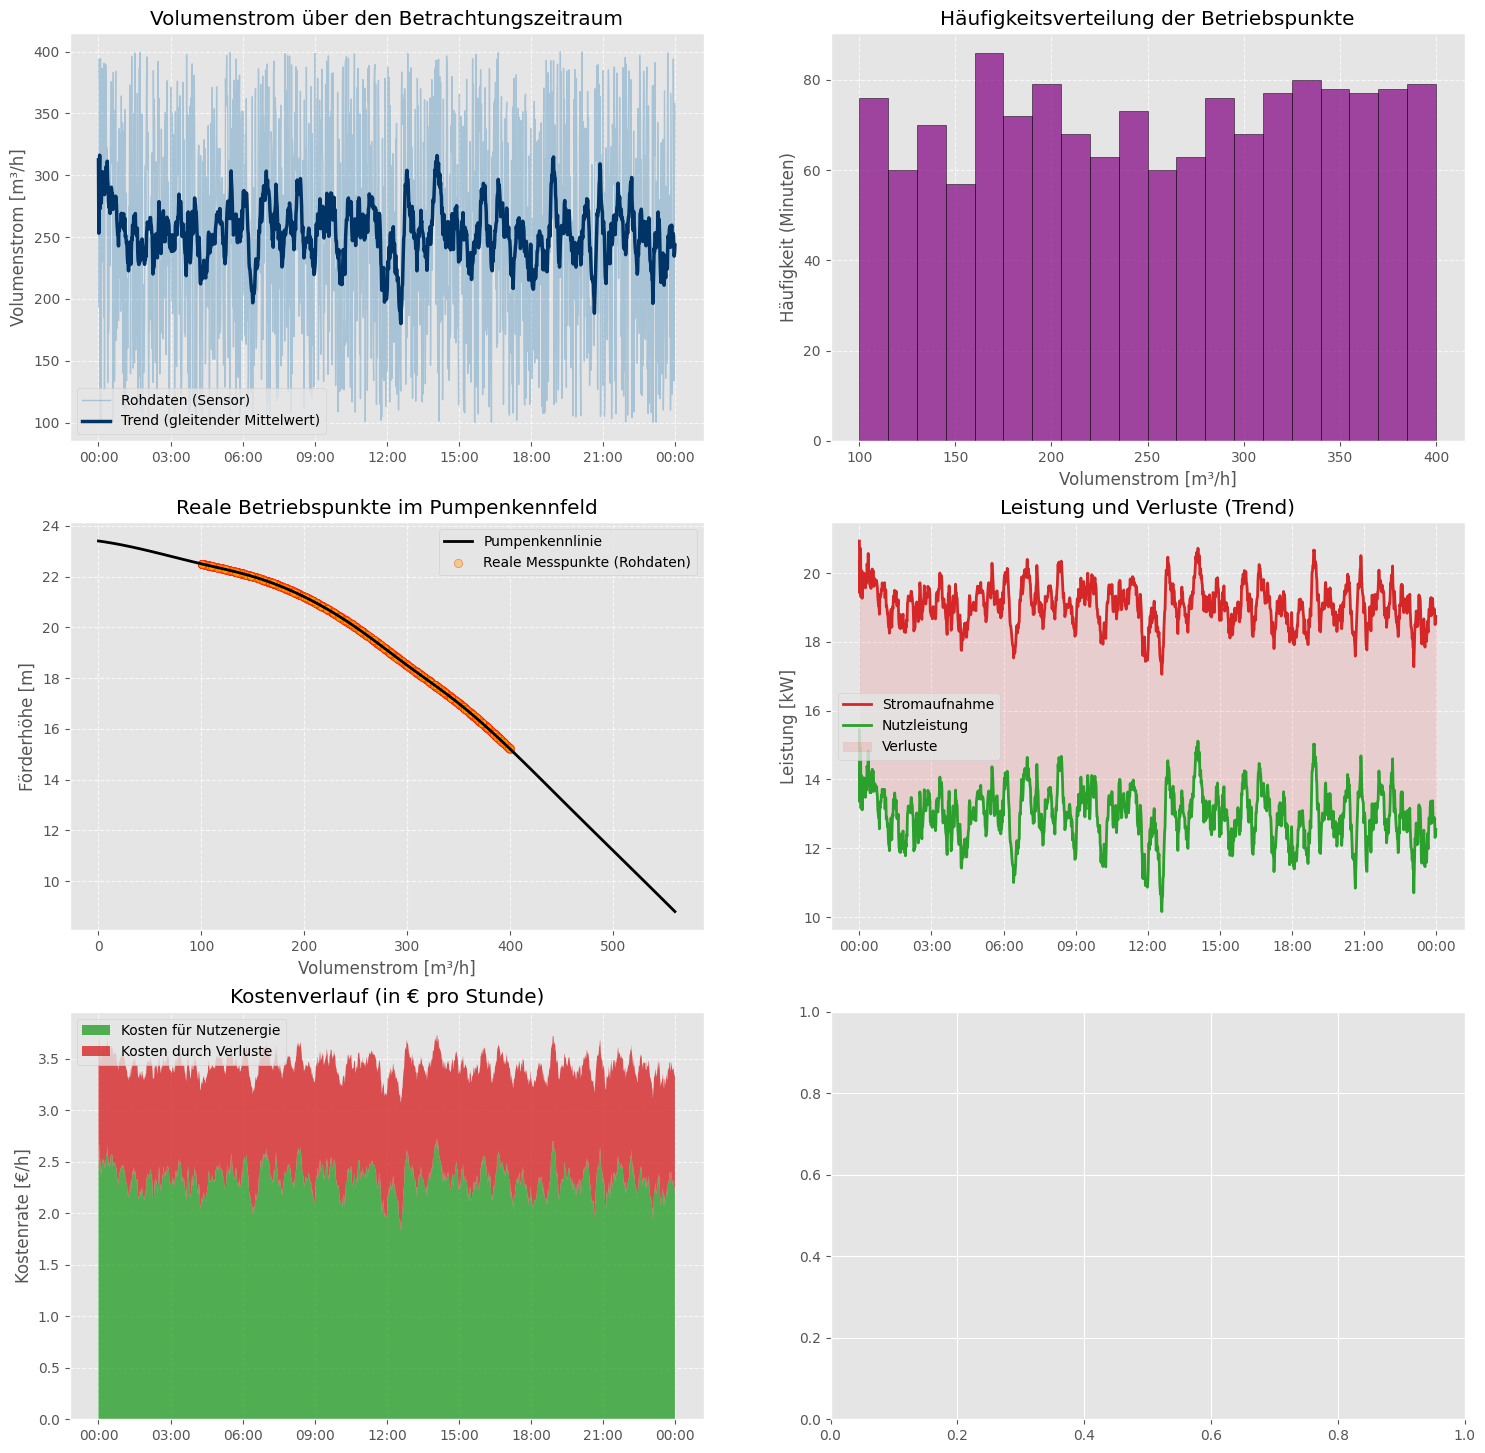

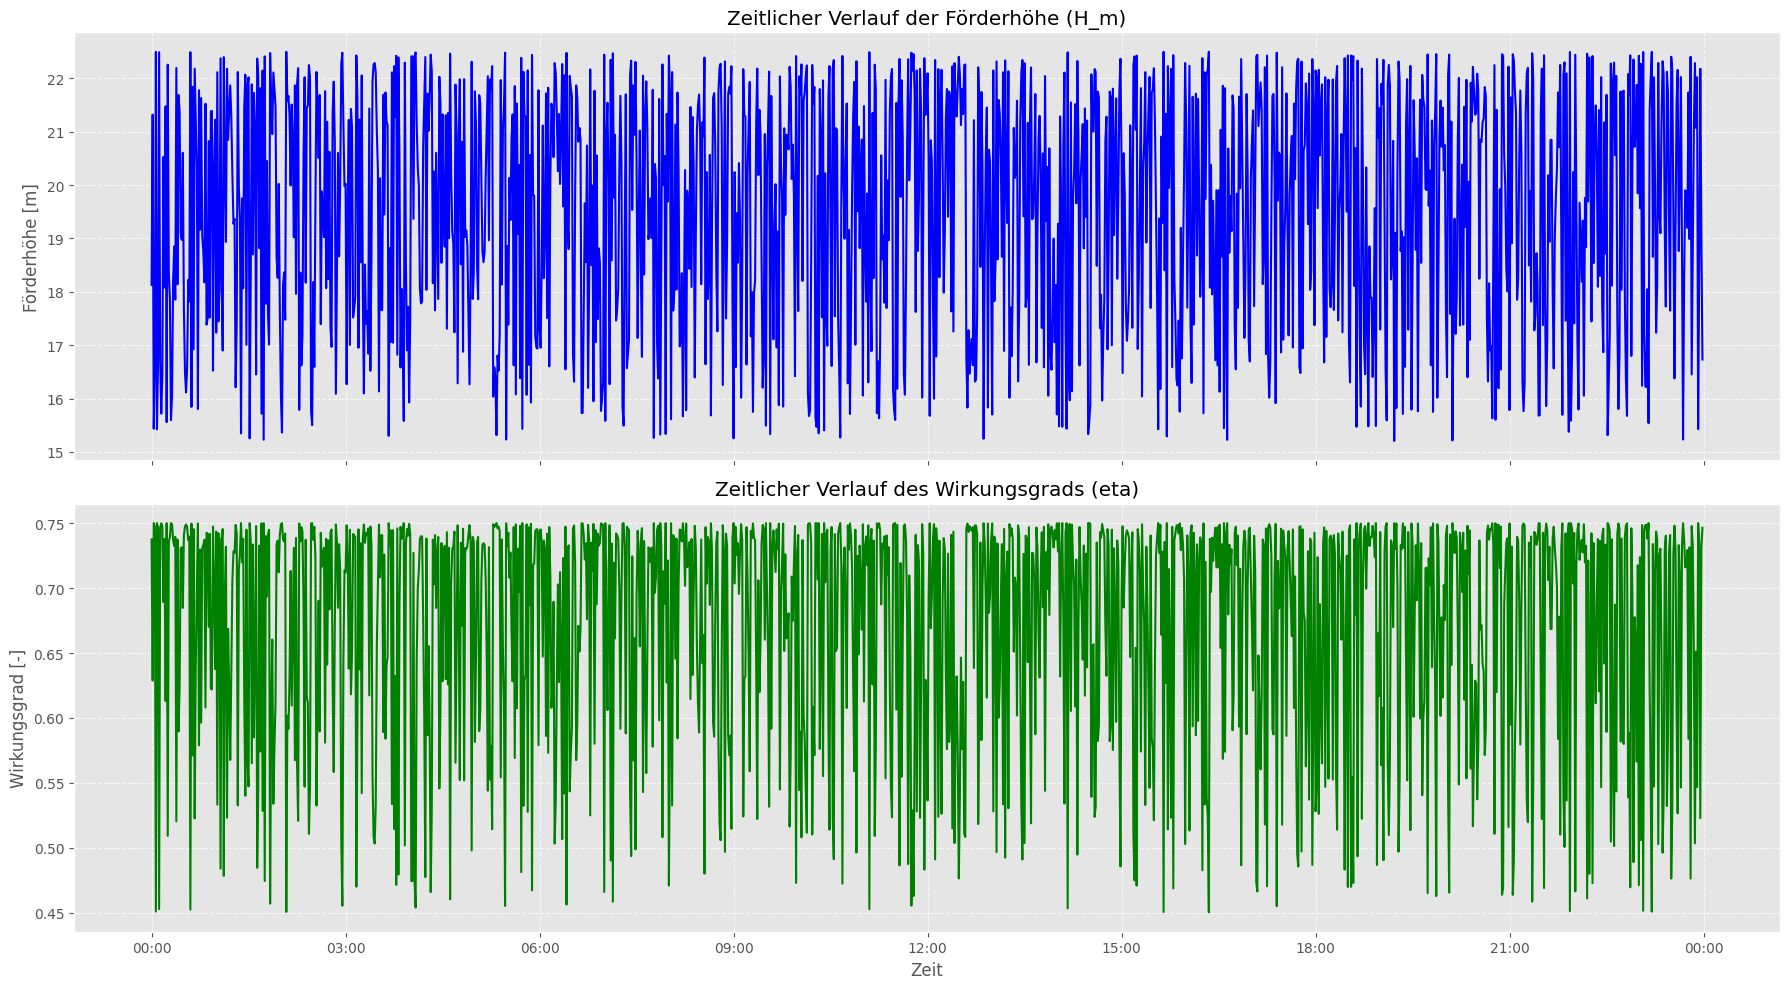

<Figure size 640x480 with 0 Axes>

In [28]:
plt.style.use('ggplot')
fig, axs = plt.subplots(3, 2, figsize=(18, 18))

# Plot 1: Volumenstrom (Zeitverlauf)
axs[0, 0].plot(df['Timestamp'], df[col_flow], color='#1f77b4', alpha=0.3, linewidth=1, label='Rohdaten (Sensor)')
axs[0, 0].plot(df['Timestamp'], df['Q_smoothed'], color='#003366', linewidth=2.5, label='Trend (gleitender Mittelwert)')
axs[0, 0].set_title('Volumenstrom über den Betrachtungszeitraum')
axs[0, 0].set_ylabel('Volumenstrom [m³/h]')
axs[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Histogramm der Betriebspunkte
axs[0, 1].hist(df[col_flow], bins=20, color='purple', alpha=0.7, edgecolor='black')
axs[0, 1].set_title('Häufigkeitsverteilung der Betriebspunkte')
axs[0, 1].set_xlabel('Volumenstrom [m³/h]')
axs[0, 1].set_ylabel('Häufigkeit (Minuten)')
axs[0, 1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: H-Q Kennfeld mit realen Messpunkten
Q_smooth_line = np.linspace(min(Q_points), max(Q_points), 100)
axs[1, 0].plot(Q_smooth_line, f_H(Q_smooth_line), color='black', linewidth=2, label='Pumpenkennlinie')
axs[1, 0].scatter(df[col_flow], df['H_m'], color='orange', alpha=0.4, edgecolor='red', label='Reale Messpunkte (Rohdaten)')
axs[1, 0].set_title('Reale Betriebspunkte im Pumpenkennfeld')
axs[1, 0].set_xlabel('Volumenstrom [m³/h]')
axs[1, 0].set_ylabel('Förderhöhe [m]')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 4: Leistungsvergleich (elektrisch vs. hydraulisch)
axs[1, 1].plot(df['Timestamp'], df['P_el_smooth']/1000, label='Stromaufnahme', color='#d62728', linewidth=2)
axs[1, 1].plot(df['Timestamp'], df['P_hyd_smooth']/1000, label='Nutzleistung', color='#2ca02c', linewidth=2)
axs[1, 1].fill_between(df['Timestamp'], df['P_hyd_smooth']/1000, df['P_el_smooth']/1000, color='red', alpha=0.1, label='Verluste')
axs[1, 1].set_title('Leistung und Verluste (Trend)')
axs[1, 1].set_ylabel('Leistung [kW]')
axs[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle='--', alpha=0.7)

# Plot 5: Stromkosten (Stacked Area)
axs[2, 0].stackplot(df['Timestamp'], df['Cost_hyd_smooth'], df['Cost_loss_smooth'],
                    labels=['Kosten für Nutzenergie', 'Kosten durch Verluste'],
                    colors=['#2ca02c', '#d62728'], alpha=0.8)
axs[2, 0].set_title('Kostenverlauf (in € pro Stunde)')
axs[2, 0].set_ylabel('Kostenrate [€/h]')
axs[2, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2, 0].legend(loc='upper left')
axs[2, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 6: Zeitlicher Verlauf von H_m und eta (im bisher leeren Feld)

# Erstelle neue Subplots für H_m und eta
fig2, (ax_h, ax_eta) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot H_m über die Zeit
ax_h.plot(df['Timestamp'], df['H_m'], color='blue', linewidth=1.5)
ax_h.set_title('Zeitlicher Verlauf der Förderhöhe (H_m)')
ax_h.set_ylabel('Förderhöhe [m]')
ax_h.grid(True, linestyle='--', alpha=0.7)

# Plot eta über die Zeit
ax_eta.plot(df['Timestamp'], df['eta'], color='green', linewidth=1.5)
ax_eta.set_title('Zeitlicher Verlauf des Wirkungsgrads (eta)')
ax_eta.set_xlabel('Zeit')
ax_eta.set_ylabel('Wirkungsgrad [-]')
ax_eta.grid(True, linestyle='--', alpha=0.7)
ax_eta.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()

# Sechstes (ursprünglich leeres) Diagrammfeld des ersten Plots ausblenden, da Plots in separaten Figuren erstellt werden
axs[2, 1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

# Dateiname der Messdaten
filename = '/content/volume_flow_data.csv'

# Messdaten einlesen
df = pd.read_csv(filename)

# Die ersten Zeilen des DataFrames anzeigen
display(df.head())

,Timestamp,Volume Flow (m^3/h)
0,2024-04-01 00:00:00,312.54
1,2024-04-01 00:01:00,193.78
2,2024-04-01 00:02:00,393.96
3,2024-04-01 00:03:00,364.70
4,2024-04-01 00:04:00,100.33


In [29]:
import numpy as np
from scipy.interpolate import interp1d

# ---------------------------------------------------------
# 1. Pumpen-Daten aus dem Hersteller-Datenblatt
# ---------------------------------------------------------
# Stützpunkte aus dem Kennfeld, basierend auf den von Ihnen bereitgestellten Daten
Q_points = np.array([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 560]) # Volumenstrom in m³/h
H_points = np.array([23.4, 23.0, 22.5, 22.0, 21.2, 20.0, 18.5, 17.0, 15.2, 13.2, 11.2, 8.8]) # Förderhöhe in m
# Pumpenwirkungsgrad-Stützpunkte (Spitzenwert 93.6% wird hier als Pumpenwirkungsgrad angenommen)
eta_pump_points = np.array([0.01, 25.0, 45.0, 55.0, 64.0, 71.3, 73.5, 74.5, 93.6, 74.0, 72.0, 68.0]) / 100.0 # Pumpenwirkungsgrad

# Interpolations-Funktionen zur stetigen Berechnung
f_H = interp1d(Q_points, H_points, kind='cubic', fill_value='extrapolate')
f_eta_pump = interp1d(Q_points, eta_pump_points, kind='cubic', fill_value='extrapolate')

In [15]:
# ---------------------------------------------------------
# 2. Messdaten einlesen & aufbereiten
# ---------------------------------------------------------

# Assuming 'Volume Flow (m^3/h)' is the correct column name from the head output
col_flow = 'Volume Flow (m^3/h)'

# Zeitstempel formatieren
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Förderhöhe und Wirkungsgrad berechnen
df['H_m'] = f_H(df[col_flow])

# Begrenzung des Wirkungsgrads auf minimal 1%, um eine Division durch Null zu vermeiden
df['eta'] = np.clip(f_eta(df[col_flow]), 0.01, 1.0)

# Glättung des Volumenstroms (15-Minuten-Fenster) zur Trendanalyse
df['Q_smoothed'] = df[col_flow].rolling(window=15, min_periods=1).mean()

In [31]:
# ---------------------------------------------------------
# 3. Physikalische & Wirtschaftliche Berechnungen
# ---------------------------------------------------------
rho = 1033 # Dichte von Wasser (kg/m³) - Aktualisiert auf 1033 kg/m³
g = 9.81   # Erdbeschleunigung (m/s²)
eta_motor_const = 0.936 # Konstanter Motorenwirkungsgrad von 93.6%

# Hydraulische Leistung (Umrechnung von m³/h in m³/s)
df['P_hyd_W'] = rho * g * (df[col_flow] / 3600) * df['H_m']

# Mechanische Leistung an der Pumpenwelle (Input für Pumpe)
df['P_mech_W'] = df['P_hyd_W'] / df['eta_pump']

# Gesamtwirkungsgrad (Pumpe * Motor)
df['eta_overall'] = df['eta_pump'] * eta_motor_const

# Elektrische Leistung (Input für Motor)
df['P_el_W'] = df['P_mech_W'] / eta_motor_const

# Energieberechnung in kWh (Messintervall 1 Minute = 1/60 h)
delta_t_h = 1 / 60
df['E_hyd_kWh'] = (df['P_hyd_W'] / 1000) * delta_t_h
df['E_mech_kWh'] = (df['P_mech_W'] / 1000) * delta_t_h
df['E_el_kWh'] = (df['P_el_W'] / 1000) * delta_t_h

# Energieverluste aufschlüsseln
df['E_motor_loss_kWh'] = df['E_el_kWh'] - df['E_mech_kWh']
df['E_pump_loss_kWh'] = df['E_mech_kWh'] - df['E_hyd_kWh']
df['E_total_loss_kWh'] = df['E_el_kWh'] - df['E_hyd_kWh'] # Gesamte nicht hydraulisch genutzte Energie

# Stromkosten-Raten für die Visualisierung berechnen (Annahme: 0,18 € / kWh)
strompreis = 0.18
df['Cost_Rate_hyd'] = (df['P_hyd_W'] / 1000) * strompreis
df['Cost_Rate_loss'] = (df['E_total_loss_kWh'] / delta_t_h / 1000) * strompreis # Kosten für Gesamtverluste pro Stunde

# Geglättete Werte für Leistung und Kosten für die spätere Darstellung erzeugen
df['P_el_smooth'] = df['P_el_W'].rolling(window=15, min_periods=1).mean()
df['P_mech_smooth'] = df['P_mech_W'].rolling(window=15, min_periods=1).mean()
df['P_hyd_smooth'] = df['P_hyd_W'].rolling(window=15, min_periods=1).mean()
df['Cost_hyd_smooth'] = df['Cost_Rate_hyd'].rolling(window=15, min_periods=1).mean()
df['Cost_loss_smooth'] = df['Cost_Rate_loss'].rolling(window=15, min_periods=1).mean()

In [32]:
# ---------------------------------------------------------
# 4. Numerische Ausgabe der Gesamtwerte
# ---------------------------------------------------------

# Berechnungen für die Zusammenfassung
duration_h = (df['Timestamp'].iloc[-1] - df['Timestamp'].iloc[0]).total_seconds() / 3600
mean_Q = df[col_flow].mean()

total_hyd_kWh = df['E_hyd_kWh'].sum()
total_mech_kWh = df['E_mech_kWh'].sum()
total_el_kWh = df['E_el_kWh'].sum()

total_motor_loss_kWh = df['E_motor_loss_kWh'].sum()
total_pump_loss_kWh = df['E_pump_loss_kWh'].sum()
total_loss_kWh = df['E_total_loss_kWh'].sum()

avg_P_hyd_W = df['P_hyd_W'].mean()
avg_P_mech_W = df['P_mech_W'].mean()
avg_P_el_W = df['P_el_W'].mean()

avg_eta_pump = (total_hyd_kWh / total_mech_kWh) * 100
avg_eta_overall = (total_hyd_kWh / total_el_kWh) * 100

total_cost = total_el_kWh * strompreis
loss_cost = total_loss_kWh * strompreis
cost_share_losses = (loss_cost / total_cost) * 100 if total_cost > 0 else 0


print("--- TECHNISCHE AUSWERTUNG --- ")
print(f"Messdauer:                      {duration_h:.2f} Stunden")
print(f"Mittlerer Volumenstrom:         {mean_Q:.2f} m³/h")
print(f"Mittlere hydraulische Leistung: {avg_P_hyd_W / 1000:.2f} kW")
print(f"Mittlere Pumpenleistung:        {avg_P_mech_W / 1000:.2f} kW")
print(f"Mittlere elektrische Leistung:   {avg_P_el_W / 1000:.2f} kW")
print(f"Hydraulisch genutzte Energie:   {total_hyd_kWh:.2f} kWh")
print(f"Energie an der Pumpenwelle:     {total_mech_kWh:.2f} kWh")
print(f"Elektrische Energie inkl. Motor: {total_el_kWh:.2f} kWh")
print(f"Pumpenverluste:                 {total_pump_loss_kWh:.2f} kWh")
print(f"Motorverluste:                  {total_motor_loss_kWh:.2f} kWh")
print(f"Gesamte nicht-hydr. Energie:    {total_loss_kWh:.2f} kWh")
print(f"Mittlerer Pumpenwirkungsgrad:   {avg_eta_pump:.2f} %")
print(f"Mittlerer Gesamtwirkungsgrad:   {avg_eta_overall:.2f} %")

print("\n--- WIRTSCHAFTLICHE AUSWERTUNG ---")
print(f"Industriestrompreis:            {strompreis:.2f} €/kWh")
print(f"Betriebskosten im Messzeitraum: {total_cost:.2f} €")
print(f"Kostenanteil nicht-hydr. Energie: {cost_share_losses:.2f} %")
print("----------------------------------------------")

--- TECHNISCHE AUSWERTUNG --- 
Messdauer:                      23.98 Stunden
Mittlerer Volumenstrom:         253.39 m³/h
Mittlere hydraulische Leistung: 13.39 kW
Mittlere Pumpenleistung:        19.29 kW
Mittlere elektrische Leistung:   20.61 kW
Hydraulisch genutzte Energie:   321.25 kWh
Energie an der Pumpenwelle:     463.00 kWh
Elektrische Energie inkl. Motor: 494.66 kWh
Pumpenverluste:                 141.75 kWh
Motorverluste:                  31.66 kWh
Gesamte nicht-hydr. Energie:    173.41 kWh
Mittlerer Pumpenwirkungsgrad:   69.38 %
Mittlerer Gesamtwirkungsgrad:   64.94 %

--- WIRTSCHAFTLICHE AUSWERTUNG ---
Industriestrompreis:            0.18 €/kWh
Betriebskosten im Messzeitraum: 89.04 €
Kostenanteil nicht-hydr. Energie: 35.06 %
----------------------------------------------


### 6. Durchschnittliche Leistung pro Stunde

In [18]:
avg_P_hyd_W = df['P_hyd_W'].mean()
avg_P_el_W = df['P_el_W'].mean()

print(f"Durchschnittliche hydraulische Leistung: {avg_P_hyd_W / 1000:.2f} kW")
print(f"Durchschnittliche elektrische Leistung: {avg_P_el_W / 1000:.2f} kW")

Durchschnittliche hydraulische Leistung: 12.96 kW
Durchschnittliche elektrische Leistung: 19.08 kW


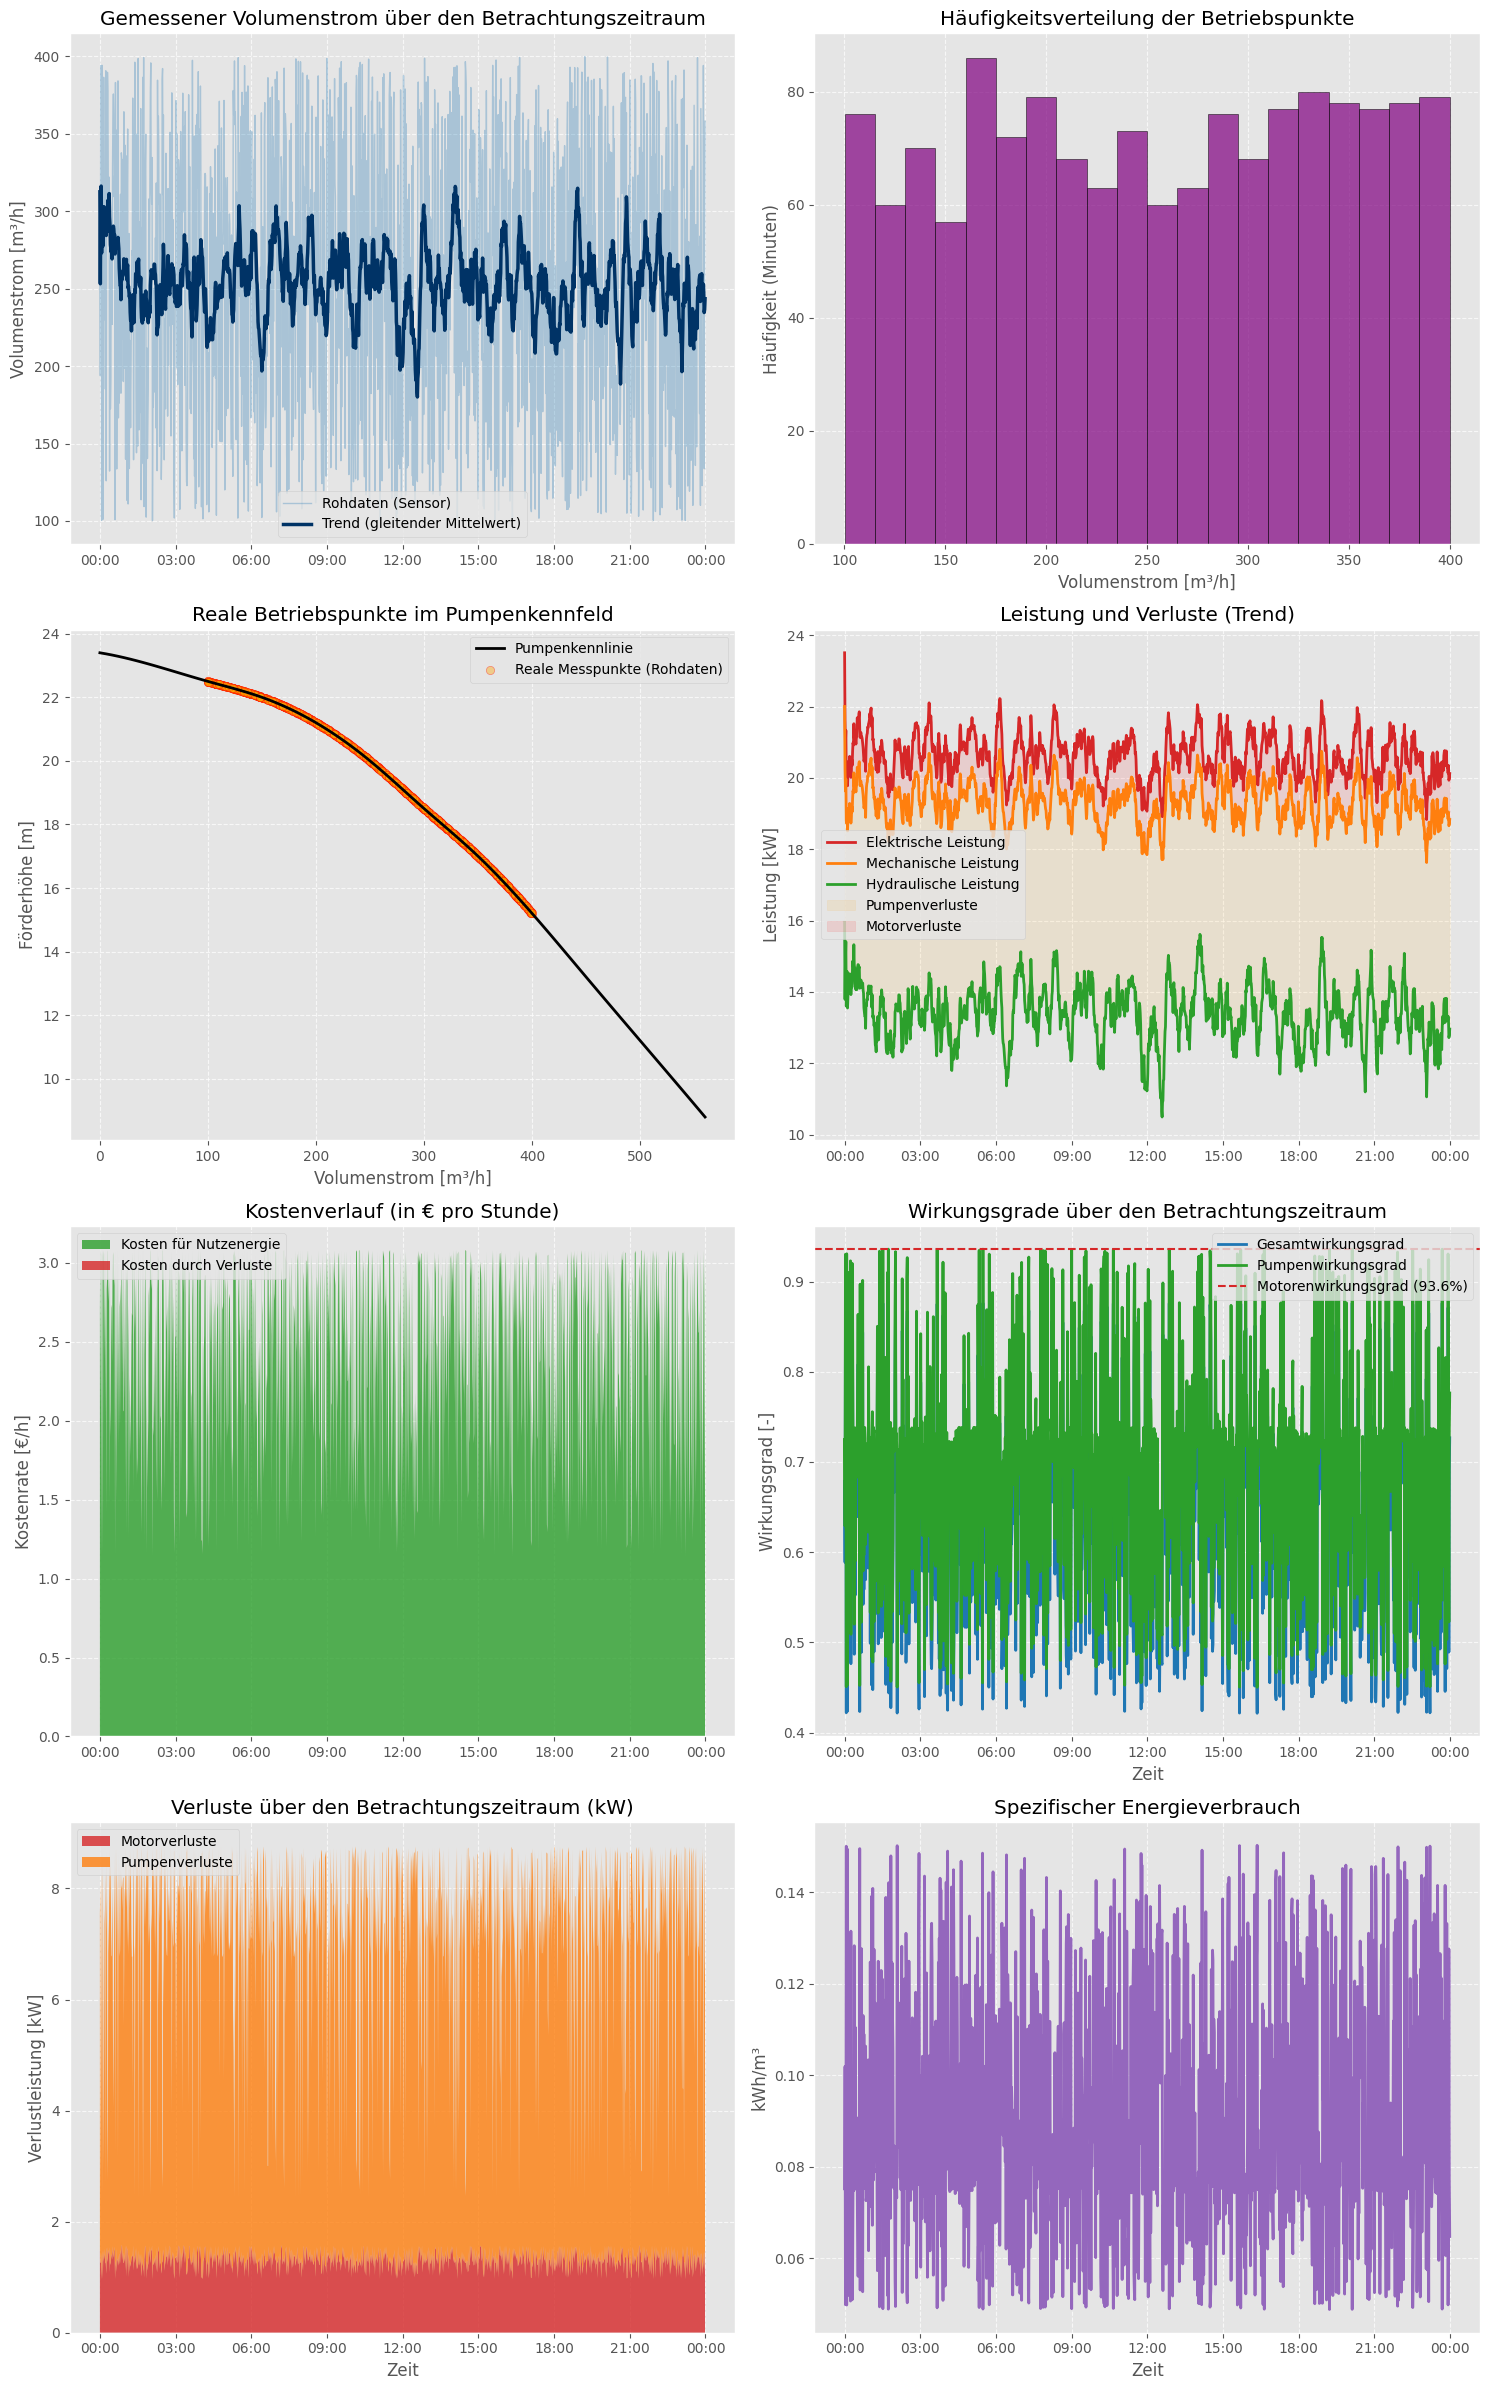

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------------------------------------------------------
# 5. Diagramme erstellen
# ---------------------------------------------------------
plt.style.use('ggplot')
fig, axs = plt.subplots(4, 2, figsize=(15, 24)) # Erhöhte Zeilen für neue Plots

# Plot 1: Volumenstrom (Zeitverlauf)
axs[0, 0].plot(df['Timestamp'], df[col_flow], color='#1f77b4', alpha=0.3, linewidth=1, label='Rohdaten (Sensor)')
axs[0, 0].plot(df['Timestamp'], df['Q_smoothed'], color='#003366', linewidth=2.5, label='Trend (gleitender Mittelwert)')
axs[0, 0].set_title('Gemessener Volumenstrom über den Betrachtungszeitraum')
axs[0, 0].set_ylabel('Volumenstrom [m³/h]')
axs[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Histogramm
axs[0, 1].hist(df[col_flow], bins=20, color='purple', alpha=0.7, edgecolor='black')
axs[0, 1].set_title('Häufigkeitsverteilung der Betriebspunkte')
axs[0, 1].set_xlabel('Volumenstrom [m³/h]')
axs[0, 1].set_ylabel('Häufigkeit (Minuten)')
axs[0, 1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: H-Q Kennfeld
Q_smooth_line = np.linspace(min(Q_points), max(Q_points), 100) # Use the range of provided Q_points
axs[1, 0].plot(Q_smooth_line, f_H(Q_smooth_line), color='black', linewidth=2, label='Pumpenkennlinie')
axs[1, 0].scatter(df[col_flow], df['H_m'], color='orange', alpha=0.4, edgecolor='red', label='Reale Messpunkte (Rohdaten)')
axs[1, 0].set_title('Reale Betriebspunkte im Pumpenkennfeld')
axs[1, 0].set_xlabel('Volumenstrom [m³/h]')
axs[1, 0].set_ylabel('Förderhöhe [m]')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 4: Leistungsvergleich (kW)
axs[1, 1].plot(df['Timestamp'], df['P_el_smooth']/1000, label='Elektrische Leistung', color='#d62728', linewidth=2)
axs[1, 1].plot(df['Timestamp'], df['P_mech_smooth']/1000, label='Mechanische Leistung', color='#ff7f0e', linewidth=2)
axs[1, 1].plot(df['Timestamp'], df['P_hyd_smooth']/1000, label='Hydraulische Leistung', color='#2ca02c', linewidth=2)
axs[1, 1].fill_between(df['Timestamp'], df['P_hyd_smooth']/1000, df['P_mech_smooth']/1000, color='orange', alpha=0.1, label='Pumpenverluste')
axs[1, 1].fill_between(df['Timestamp'], df['P_mech_smooth']/1000, df['P_el_smooth']/1000, color='red', alpha=0.1, label='Motorverluste')
axs[1, 1].set_title('Leistung und Verluste (Trend)')
axs[1, 1].set_ylabel('Leistung [kW]')
axs[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle='--', alpha=0.7)

# Plot 5: Stromkosten (Stacked Area)
axs[2, 0].stackplot(df['Timestamp'], df['Cost_Rate_hyd'], df['Cost_Rate_loss'],
                    labels=['Kosten für Nutzenergie', 'Kosten durch Verluste'],
                    colors=['#2ca02c', '#d62728'], alpha=0.8)
axs[2, 0].set_title('Kostenverlauf (in € pro Stunde)')
axs[2, 0].set_ylabel('Kostenrate [€/h]')
axs[2, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2, 0].legend(loc='upper left')
axs[2, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 6: Wirkungsgrade über die Zeit
axs[2, 1].plot(df['Timestamp'], df['eta_overall'], label='Gesamtwirkungsgrad', color='#1f77b4', linewidth=2)
axs[2, 1].plot(df['Timestamp'], df['eta_pump'], label='Pumpenwirkungsgrad', color='#2ca02c', linewidth=2)
axs[2, 1].axhline(y=eta_motor_const, color='#d62728', linestyle='--', label=f'Motorenwirkungsgrad ({eta_motor_const*100:.1f}%)')
axs[2, 1].set_title('Wirkungsgrade über den Betrachtungszeitraum')
axs[2, 1].set_ylabel('Wirkungsgrad [-]')
axs[2, 1].set_xlabel('Zeit')
axs[2, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2, 1].legend()
axs[2, 1].grid(True, linestyle='--', alpha=0.7)

# Plot 7: Verluste aufgeschlüsselt über die Zeit
axs[3, 0].stackplot(df['Timestamp'], df['E_motor_loss_kWh'] / delta_t_h, df['E_pump_loss_kWh'] / delta_t_h,
                    labels=['Motorverluste', 'Pumpenverluste'],
                    colors=['#d62728', '#ff7f0e'], alpha=0.8)
axs[3, 0].set_title('Verluste über den Betrachtungszeitraum (kW)')
axs[3, 0].set_ylabel('Verlustleistung [kW]')
axs[3, 0].set_xlabel('Zeit')
axs[3, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[3, 0].legend(loc='upper left')
axs[3, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 8: Spezifischer Energieverbrauch
df['E_spec_kWh_m3'] = df['E_el_kWh'] / (df[col_flow] * delta_t_h)
axs[3, 1].plot(df['Timestamp'], df['E_spec_kWh_m3'], color='#9467bd', linewidth=2)
axs[3, 1].set_title('Spezifischer Energieverbrauch')
axs[3, 1].set_ylabel('kWh/m³')
axs[3, 1].set_xlabel('Zeit')
axs[3, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[3, 1].grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()